# Parte 1 — Diagnóstico do Funil

Este notebook apresenta a análise do funil de propostas de crédito com garantia de imóvel, incluindo tratamento dos dados, análise das perdas do funil, conversão, desempenho dos canais e características associadas à contratação.

Os dados utilizados foram fornecidos exclusivamente para o desafio prático do processo seletivo do AI & Data Lab do Bari.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df_raw = pd.read_csv("/content/propostas_credito.csv")

print(f"Linhas: {df_raw.shape[0]}")
print(f"Colunas: {df_raw.shape[1]}")

df_raw.head()


Linhas: 6400
Colunas: 19


,id_proposta,data_entrada,canal_origem,cidade,uf,tipo_imovel,valor_imovel,valor_solicitado,prazo_meses,score_credito,idade_cliente,renda_mensal_declarada,flag_cliente_recorrente,consultor_id,etapa_max_funil,status_final,tempo_analise_dias,data_assinatura_contrato,taxa_juros_aa
0,PR-000001,2024-07-12,Mídia paga,Goiânia,GO,Apartamento,461158.85,313370.07,120,681,33,5270.65,0,CONS-016,6,Contratada,17,2024-07-29,1.37
1,PR-000002,2025-07-18,Organico,Santos,SP,Terreno,2264057.22,1016814.02,240,672,52,4076.09,0,CONS-029,3,Sem retorno,31,NaN,NaN
2,PR-000003,2025-02-03,Organico,Brasília,DF,Sala comercial,646299.62,296412.10,180,644,65,3144.50,0,CONS-012,3,Desistiu,33,NaN,NaN
3,PR-000004,2025-03-11,Mídia paga,Santos,SP,Apartamento,523466.29,291062.73,180,847,45,19433.79,0,CONS-015,4,Problema garantia,37,NaN,NaN
4,PR-000005,2025-03-31,Correspondente,Recife,PE,Imóvel rural,862253.74,383285.39,84,686,35,4667.16,0,CONS-029,2,Desistiu,14,NaN,NaN


## 2. Tratamento e qualidade dos dados

A base foi preservada originalmente em `df_raw`. Os tratamentos abaixo são aplicados em uma cópia (`df`), evitando alterações no arquivo bruto.

As decisões de limpeza buscaram corrigir problemas de formato quando havia evidência suficiente, preservar anomalias quando não era possível determinar o valor correto e documentar limitações que podem afetar a interpretação dos resultados.


In [13]:
# ==========================================================
# TRATAMENTO DA BASE
# Sempre parte da base bruta para evitar tratamentos duplicados
# ==========================================================

df = df_raw.copy()

# 1. Remoção de terrenos — regra explícita do desafio
df = df[df["tipo_imovel"] != "Terreno"].copy()


# 2. Padronização de valor_imovel
df["valor_imovel"] = (
    df["valor_imovel"]
    .astype(str)
    .str.replace("R$", "", regex=False)
    .str.strip()
)

df["valor_imovel"] = pd.to_numeric(
    df["valor_imovel"],
    errors="coerce"
)


# 3. Padronização dos canais
mapa_canais = {
    "mídia paga": "Mídia paga",
    "indicação": "Indicação",
    "organico": "Organico"
}

df["canal_origem"] = (
    df["canal_origem"]
    .astype(str)
    .str.strip()
    .replace(mapa_canais)
)


# 4. Conversão das datas de entrada
# format="mixed" permite os dois formatos encontrados na base
df["data_entrada"] = pd.to_datetime(
    df["data_entrada"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)


# 5. Etapa utilizada na análise
# Mantemos etapa_max_funil original e criamos uma nova coluna
df["etapa_funil_analise"] = (
    pd.to_numeric(df["etapa_max_funil"], errors="coerce")
    .clip(upper=6)
)


# 6. Cálculo do LTV
df["ltv_calculado"] = (
    df["valor_solicitado"] / df["valor_imovel"]
)

df["flag_ltv_acima_60"] = (
    df["ltv_calculado"] > 0.60
)


# 7. Sinalização de idade anômala
df["flag_idade_anomala"] = (
    df["idade_cliente"] < 18
)


# 8. Conversão das datas de assinatura
df["data_assinatura_contrato"] = pd.to_datetime(
    df["data_assinatura_contrato"],
    errors="coerce"
)

df["flag_data_assinatura_invalida"] = (
    df["data_assinatura_contrato"].notna()
    & (df["data_assinatura_contrato"] < df["data_entrada"])
)


# ==========================================================
# VALIDAÇÃO
# ==========================================================

print("=== RESUMO DA BASE TRATADA ===")
print(f"Propostas analisadas: {len(df):,}")
print(f"IDs duplicados: {df['id_proposta'].duplicated().sum()}")
print(f"Valor do imóvel ausente: {df['valor_imovel'].isna().sum()}")
print(f"Data de entrada inválida: {df['data_entrada'].isna().sum()}")
print(f"LTV ausente: {df['ltv_calculado'].isna().sum()}")
print(f"LTV > 60%: {df['flag_ltv_acima_60'].sum()}")
print(f"Idades < 18: {df['flag_idade_anomala'].sum()}")
print(f"Datas de assinatura inválidas: {df['flag_data_assinatura_invalida'].sum()}")

=== RESUMO DA BASE TRATADA ===
Propostas analisadas: 5,865
IDs duplicados: 0
Valor do imóvel ausente: 0
Data de entrada inválida: 0
LTV ausente: 0
LTV > 60%: 904
Idades < 18: 1
Datas de assinatura inválidas: 1


## 3. Onde o funil perde mais valor?

Para mensurar o valor potencial perdido no funil, utilizei o `valor_solicitado` das propostas que não chegaram à contratação.

Esse valor deve ser interpretado como **volume potencial de crédito solicitado**, e não como receita ou lucro perdido pelo Bari, já que a base não fornece margem, receita esperada ou valor efetivamente contratado.

Uma proposta foi considerada perdida na última etapa que conseguiu atingir (`etapa_max_funil`).


In [15]:
nomes_etapas = {
    1: "Simulação",
    2: "Lead",
    3: "Análise de crédito",
    4: "Avaliação do imóvel",
    5: "Formalização",
    6: "Contratação"
}

# Propostas que não chegaram à contratação
perdas = df[df["etapa_funil_analise"] < 6].copy()

# Resumo das perdas
resumo_perdas = (
    perdas
    .groupby("etapa_funil_analise")
    .agg(
        propostas_perdidas=("id_proposta", "count"),
        valor_perdido=("valor_solicitado", "sum")
    )
    .reset_index()
)

resumo_perdas["etapa"] = resumo_perdas["etapa_funil_analise"].map(nomes_etapas)

total_valor_perdido = resumo_perdas["valor_perdido"].sum()

resumo_perdas["percentual_valor_perdido"] = (
    resumo_perdas["valor_perdido"] / total_valor_perdido * 100
)

# Versão formatada apenas para exibição
tabela_perdas = resumo_perdas[
    ["etapa", "propostas_perdidas", "valor_perdido", "percentual_valor_perdido"]
].copy()

tabela_perdas["valor_perdido"] = tabela_perdas["valor_perdido"].apply(
    lambda x: f"R$ {x / 1_000_000:.1f} mi"
)

tabela_perdas["percentual_valor_perdido"] = tabela_perdas[
    "percentual_valor_perdido"
].apply(lambda x: f"{x:.1f}%")

tabela_perdas

,etapa,propostas_perdidas,valor_perdido,percentual_valor_perdido
0,Simulação,256,R$ 97.9 mi,5.3%
1,Lead,909,R$ 346.8 mi,18.8%
2,Análise de crédito,1657,R$ 649.8 mi,35.2%
3,Avaliação do imóvel,1151,R$ 453.8 mi,24.6%
4,Formalização,764,R$ 296.1 mi,16.1%


In [16]:
taxas_perda = []

for etapa in range(1, 6):
    # Todo o volume que conseguiu chegar a esta etapa ou além
    valor_que_chegou = df.loc[
        df["etapa_funil_analise"] >= etapa,
        "valor_solicitado"
    ].sum()

    # Volume que parou exatamente nesta etapa
    valor_que_parou = df.loc[
        df["etapa_funil_analise"] == etapa,
        "valor_solicitado"
    ].sum()

    taxa = valor_que_parou / valor_que_chegou * 100

    taxas_perda.append({
        "etapa": nomes_etapas[etapa],
        "valor_que_chegou": valor_que_chegou,
        "valor_perdido": valor_que_parou,
        "taxa_perda": taxa
    })

taxas_perda = pd.DataFrame(taxas_perda)

taxas_perda[
    ["etapa", "taxa_perda"]
]

,etapa,taxa_perda
0,Simulação,4.329522
1,Lead,16.032750
2,Análise de crédito,35.776135
3,Avaliação do imóvel,38.896359
4,Formalização,41.541248


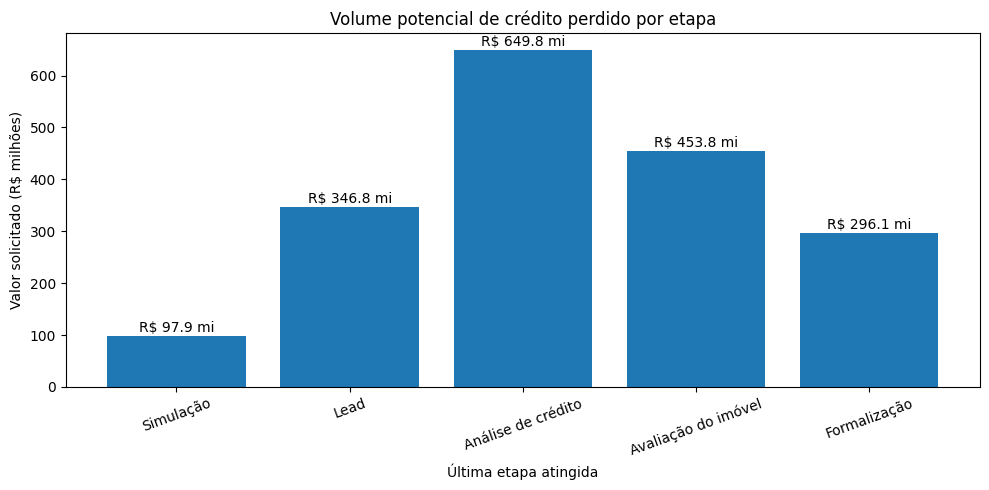

In [18]:
# Gráfico do Case

grafico_perdas = resumo_perdas.copy()

grafico_perdas["valor_perdido_milhoes"] = (
    grafico_perdas["valor_perdido"] / 1_000_000
)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    grafico_perdas["etapa"],
    grafico_perdas["valor_perdido_milhoes"]
)

plt.title("Volume potencial de crédito perdido por etapa")
plt.ylabel("Valor solicitado (R$ milhões)")
plt.xlabel("Última etapa atingida")
plt.xticks(rotation=20)

for barra in barras:
    valor = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 8,
        f"R$ {valor:.1f} mi",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Conclusão

Após a remoção dos imóveis do tipo Terreno, foram analisadas 5.865 propostas.

As propostas que não chegaram à contratação representam aproximadamente **R$ 1,84 bilhão em volume de crédito solicitado**.

A maior perda absoluta ocorre na etapa de **Análise de crédito**, onde 1.657 propostas, que somam aproximadamente **R$ 649,8 milhões**, deixaram de avançar. Isso representa cerca de **35,2% de todo o volume potencial perdido no funil**.

Entretanto, ao considerar apenas o volume que efetivamente chega a cada etapa, a **Formalização apresenta a maior perda proporcional**, com aproximadamente **41,5% do volume que chega à etapa não alcançando a contratação**.

Portanto, a Análise de crédito concentra o maior vazamento financeiro em termos absolutos, enquanto a Formalização apresenta o maior vazamento proporcional.

Os valores representam volume solicitado e não receita ou lucro perdido pelo Bari.

## 4. A percepção da liderança se confirma?

A liderança levantou duas hipóteses:

1. A conversão caiu nos últimos meses.
2. O canal de Correspondentes apresenta desempenho abaixo do esperado.

Para testar essas hipóteses, considerei como conversão a proporção de propostas que chegaram à etapa de contratação.

,mes_entrada,propostas,contratadas,taxa_conversao
0,2024-01,20,4,20.0%
1,2024-02,54,11,20.4%
2,2024-03,83,13,15.7%
3,2024-04,121,22,18.2%
4,2024-05,147,34,23.1%
5,2024-06,183,25,13.7%
6,2024-07,244,53,21.7%
7,2024-08,280,66,23.6%
8,2024-09,278,52,18.7%
9,2024-10,340,76,22.4%


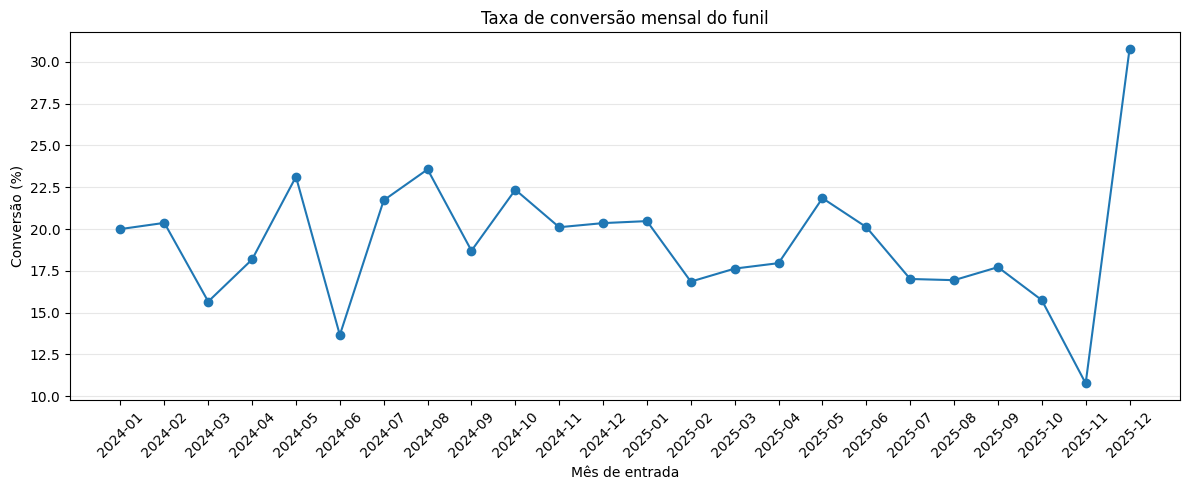


=== COMPARAÇÃO DE PERÍODOS ===
2025 - 1º semestre: 19.0%
2025 - 2º semestre: 16.9%
Jul-Nov/2024: 21.3%
Jul-Nov/2025: 16.5%


In [19]:
# Flag de contratação
df["contratada"] = df["etapa_funil_analise"] == 6

# Mês de entrada
df["mes_entrada"] = df["data_entrada"].dt.to_period("M")

# Conversão mensal
conversao_mensal = (
    df.groupby("mes_entrada")
    .agg(
        propostas=("id_proposta", "count"),
        contratadas=("contratada", "sum")
    )
    .reset_index()
)

conversao_mensal["taxa_conversao"] = (
    conversao_mensal["contratadas"] /
    conversao_mensal["propostas"] * 100
)

# Exibição
tabela_conversao = conversao_mensal.copy()
tabela_conversao["mes_entrada"] = tabela_conversao["mes_entrada"].astype(str)
tabela_conversao["taxa_conversao"] = tabela_conversao["taxa_conversao"].apply(
    lambda x: f"{x:.1f}%"
)

display(tabela_conversao)

# Gráfico
plt.figure(figsize=(12, 5))

plt.plot(
    conversao_mensal["mes_entrada"].astype(str),
    conversao_mensal["taxa_conversao"],
    marker="o"
)

plt.title("Taxa de conversão mensal do funil")
plt.ylabel("Conversão (%)")
plt.xlabel("Mês de entrada")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Comparações de períodos
primeiro_semestre_2025 = df[
    (df["data_entrada"].dt.year == 2025) &
    (df["data_entrada"].dt.month <= 6)
]

segundo_semestre_2025 = df[
    (df["data_entrada"].dt.year == 2025) &
    (df["data_entrada"].dt.month >= 7)
]

jul_nov_2024 = df[
    (df["data_entrada"].dt.year == 2024) &
    (df["data_entrada"].dt.month.between(7, 11))
]

jul_nov_2025 = df[
    (df["data_entrada"].dt.year == 2025) &
    (df["data_entrada"].dt.month.between(7, 11))
]

print("\n=== COMPARAÇÃO DE PERÍODOS ===")

print(
    f"2025 - 1º semestre: "
    f"{primeiro_semestre_2025['contratada'].mean() * 100:.1f}%"
)

print(
    f"2025 - 2º semestre: "
    f"{segundo_semestre_2025['contratada'].mean() * 100:.1f}%"
)

print(
    f"Jul-Nov/2024: "
    f"{jul_nov_2024['contratada'].mean() * 100:.1f}%"
)

print(
    f"Jul-Nov/2025: "
    f"{jul_nov_2025['contratada'].mean() * 100:.1f}%"
)

,canal_origem,propostas,contratadas,taxa_conversao,conversao_valor
0,Correspondente,1627,223,13.7%,12.3%
3,Organico,1273,255,20.0%,20.3%
2,Mídia paga,1166,250,21.4%,20.8%
1,Indicação,910,197,21.6%,20.8%
4,Parceria,889,203,22.8%,21.6%


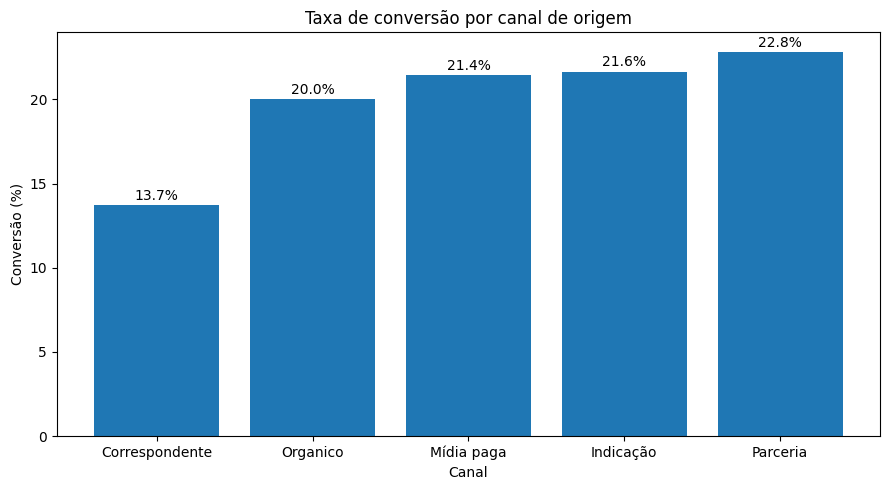


=== CORRESPONDENTES X DEMAIS CANAIS ===
Correspondentes: 13.7% (1627 propostas)
Demais canais: 21.4% (4238 propostas)


In [20]:
desempenho_canais = (
    df.groupby("canal_origem")
    .agg(
        propostas=("id_proposta", "count"),
        contratadas=("contratada", "sum"),
        valor_total=("valor_solicitado", "sum")
    )
    .reset_index()
)

desempenho_canais["taxa_conversao"] = (
    desempenho_canais["contratadas"] /
    desempenho_canais["propostas"] * 100
)

# Volume solicitado das propostas contratadas
valor_contratado_proxy = (
    df[df["contratada"]]
    .groupby("canal_origem")["valor_solicitado"]
    .sum()
)

desempenho_canais["valor_contratado_proxy"] = (
    desempenho_canais["canal_origem"]
    .map(valor_contratado_proxy)
)

desempenho_canais["conversao_valor"] = (
    desempenho_canais["valor_contratado_proxy"] /
    desempenho_canais["valor_total"] * 100
)

desempenho_canais = desempenho_canais.sort_values(
    "taxa_conversao"
)

# Tabela para exibição
tabela_canais = desempenho_canais[
    [
        "canal_origem",
        "propostas",
        "contratadas",
        "taxa_conversao",
        "conversao_valor"
    ]
].copy()

tabela_canais["taxa_conversao"] = tabela_canais[
    "taxa_conversao"
].apply(lambda x: f"{x:.1f}%")

tabela_canais["conversao_valor"] = tabela_canais[
    "conversao_valor"
].apply(lambda x: f"{x:.1f}%")

display(tabela_canais)

# Gráfico
plt.figure(figsize=(9, 5))

barras = plt.bar(
    desempenho_canais["canal_origem"],
    desempenho_canais["taxa_conversao"]
)

plt.title("Taxa de conversão por canal de origem")
plt.ylabel("Conversão (%)")
plt.xlabel("Canal")

for barra in barras:
    valor = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.3,
        f"{valor:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Correspondentes vs demais canais
correspondentes = df[df["canal_origem"] == "Correspondente"]
demais = df[df["canal_origem"] != "Correspondente"]

print("\n=== CORRESPONDENTES X DEMAIS CANAIS ===")

print(
    f"Correspondentes: "
    f"{correspondentes['contratada'].mean() * 100:.1f}% "
    f"({len(correspondentes)} propostas)"
)

print(
    f"Demais canais: "
    f"{demais['contratada'].mean() * 100:.1f}% "
    f"({len(demais)} propostas)"
)

### Conclusão — percepção da liderança

A percepção da liderança é **parcialmente confirmada pelos dados**.

#### A conversão caiu?

Há evidências de queda recente na conversão. No primeiro semestre de 2025, aproximadamente **19,0%** das propostas chegaram à contratação, enquanto no segundo semestre a taxa caiu para **16,9%**, uma redução de **2,1 pontos percentuais**.

A queda fica ainda mais evidente ao comparar períodos equivalentes: entre julho e novembro de 2024, a conversão foi de aproximadamente **21,3%**, enquanto no mesmo período de 2025 caiu para **16,5%**, uma redução de aproximadamente **4,8 pontos percentuais**.

Apesar disso, a série mensal apresenta oscilações e alguns meses possuem menor volume de propostas. Por esse motivo, considero a evidência de queda **moderada**, e não conclusiva sobre a existência de uma tendência estrutural de longo prazo.

#### O canal de Correspondentes está performando mal?

Os dados sustentam de forma mais clara essa percepção.

O canal de **Correspondentes apresentou conversão de 13,7% em 1.627 propostas**, enquanto os demais canais, em conjunto, apresentaram aproximadamente **21,4%** de conversão.

A diferença também aparece quando analisamos o volume financeiro: aproximadamente **12,3% do valor solicitado pelos Correspondentes** chegou à contratação, abaixo do desempenho observado nos demais canais.

Assim, considero **alta a confiança de que existe uma associação entre o canal Correspondente e uma menor taxa de contratação dentro desta base**.

Entretanto, essa análise não demonstra que o canal seja a causa da menor conversão. É possível que os Correspondentes recebam propostas com características diferentes, como maior LTV, menor score de crédito ou outros fatores associados a uma menor probabilidade de contratação. Essas variáveis serão analisadas na próxima etapa.

## 5. Quais características mais se associam à contratação?

Para identificar características associadas à contratação, comparei a taxa de conversão entre grupos de propostas segundo canal, LTV, score de crédito, tipo de imóvel, ticket solicitado, região, prazo e recorrência do cliente.

Esta é uma análise descritiva de associação. Diferenças de conversão não significam, por si só, que uma característica seja a causa da contratação.

In [21]:
# ==========================================================
# CRIAÇÃO DAS FAIXAS PARA ANÁLISE
# ==========================================================

# LTV
df["faixa_ltv"] = pd.cut(
    df["ltv_calculado"],
    bins=[-float("inf"), 0.40, 0.50, 0.60, float("inf")],
    labels=["Até 40%", "40%–50%", "50%–60%", "Acima de 60%"]
)

# Score
df["faixa_score"] = pd.cut(
    df["score_credito"],
    bins=[-float("inf"), 599, 649, 699, 749, float("inf")],
    labels=["<600", "600–649", "650–699", "700–749", "750+"]
)

# Ticket solicitado
df["faixa_ticket"] = pd.cut(
    df["valor_solicitado"],
    bins=[0, 200000, 300000, 400000, 600000, float("inf")],
    labels=[
        "Até R$ 200 mil",
        "R$ 200–300 mil",
        "R$ 300–400 mil",
        "R$ 400–600 mil",
        "Acima de R$ 600 mil"
    ],
    include_lowest=True
)

# Região
mapa_regioes = {
    "SP": "Sudeste",
    "RJ": "Sudeste",
    "MG": "Sudeste",
    "PR": "Sul",
    "SC": "Sul",
    "RS": "Sul",
    "PE": "Nordeste",
    "BA": "Nordeste",
    "GO": "Centro-Oeste",
    "DF": "Centro-Oeste"
}

df["regiao"] = df["uf"].map(mapa_regioes)


# ==========================================================
# FUNÇÃO PARA CALCULAR CONVERSÃO
# ==========================================================

def analisar_caracteristica(coluna):
    tabela = (
        df.groupby(coluna, observed=True)
        .agg(
            propostas=("id_proposta", "count"),
            contratadas=("contratada", "sum")
        )
        .reset_index()
    )

    tabela["taxa_conversao"] = (
        tabela["contratadas"] / tabela["propostas"] * 100
    )

    return tabela


# ==========================================================
# ANÁLISES
# ==========================================================

analises = {
    "Canal": analisar_caracteristica("canal_origem"),
    "LTV": analisar_caracteristica("faixa_ltv"),
    "Score": analisar_caracteristica("faixa_score"),
    "Tipo de imóvel": analisar_caracteristica("tipo_imovel"),
    "Ticket": analisar_caracteristica("faixa_ticket"),
    "Região": analisar_caracteristica("regiao"),
    "Prazo": analisar_caracteristica("prazo_meses"),
    "Cliente recorrente": analisar_caracteristica("flag_cliente_recorrente")
}

# Exibe cada tabela
for nome, tabela in analises.items():
    print(f"\n=== {nome.upper()} ===")

    exibicao = tabela.copy()
    exibicao["taxa_conversao"] = exibicao["taxa_conversao"].apply(
        lambda x: f"{x:.1f}%"
    )

    display(exibicao)


# ==========================================================
# COMPARAÇÃO DA AMPLITUDE ENTRE GRUPOS
# ==========================================================

resumo_associacoes = []

for nome, tabela in analises.items():

    melhor = tabela.loc[tabela["taxa_conversao"].idxmax()]
    pior = tabela.loc[tabela["taxa_conversao"].idxmin()]

    coluna_grupo = tabela.columns[0]

    resumo_associacoes.append({
        "caracteristica": nome,
        "melhor_grupo": melhor[coluna_grupo],
        "melhor_conversao": melhor["taxa_conversao"],
        "pior_grupo": pior[coluna_grupo],
        "pior_conversao": pior["taxa_conversao"],
        "diferenca_pp": (
            melhor["taxa_conversao"] - pior["taxa_conversao"]
        )
    })

resumo_associacoes = pd.DataFrame(resumo_associacoes).sort_values(
    "diferenca_pp",
    ascending=False
)

resumo_exibicao = resumo_associacoes.copy()

resumo_exibicao["melhor_conversao"] = resumo_exibicao[
    "melhor_conversao"
].apply(lambda x: f"{x:.1f}%")

resumo_exibicao["pior_conversao"] = resumo_exibicao[
    "pior_conversao"
].apply(lambda x: f"{x:.1f}%")

resumo_exibicao["diferenca_pp"] = resumo_exibicao[
    "diferenca_pp"
].apply(lambda x: f"{x:.1f} p.p.")

display(resumo_exibicao)


=== CANAL ===


,canal_origem,propostas,contratadas,taxa_conversao
0,Correspondente,1627,223,13.7%
1,Indicação,910,197,21.6%
2,Mídia paga,1166,250,21.4%
3,Organico,1273,255,20.0%
4,Parceria,889,203,22.8%



=== LTV ===


,faixa_ltv,propostas,contratadas,taxa_conversao
0,Até 40%,1150,235,20.4%
1,40%–50%,1959,451,23.0%
2,50%–60%,1852,333,18.0%
3,Acima de 60%,904,109,12.1%



=== SCORE ===


...


=== PRAZO ===


,prazo_meses,propostas,contratadas,taxa_conversao
0,60,1185,218,18.4%
1,84,1231,233,18.9%
2,120,1167,228,19.5%
3,180,1174,220,18.7%
4,240,1108,229,20.7%



=== CLIENTE RECORRENTE ===


,flag_cliente_recorrente,propostas,contratadas,taxa_conversao
0,0,4733,867,18.3%
1,1,1132,261,23.1%


,caracteristica,melhor_grupo,melhor_conversao,pior_grupo,pior_conversao,diferenca_pp
2,Score,750+,31.7%,<600,9.6%,22.1 p.p.
1,LTV,40%–50%,23.0%,Acima de 60%,12.1%,11.0 p.p.
0,Canal,Parceria,22.8%,Correspondente,13.7%,9.1 p.p.
5,Região,Centro-Oeste,22.3%,Sul,17.1%,5.2 p.p.
7,Cliente recorrente,1.0,23.1%,0.0,18.3%,4.7 p.p.
4,Ticket,Até R$ 200 mil,20.7%,Acima de R$ 600 mil,16.3%,4.4 p.p.
3,Tipo de imóvel,Sala comercial,20.9%,Casa,18.2%,2.6 p.p.
6,Prazo,240.0,20.7%,60.0,18.4%,2.3 p.p.


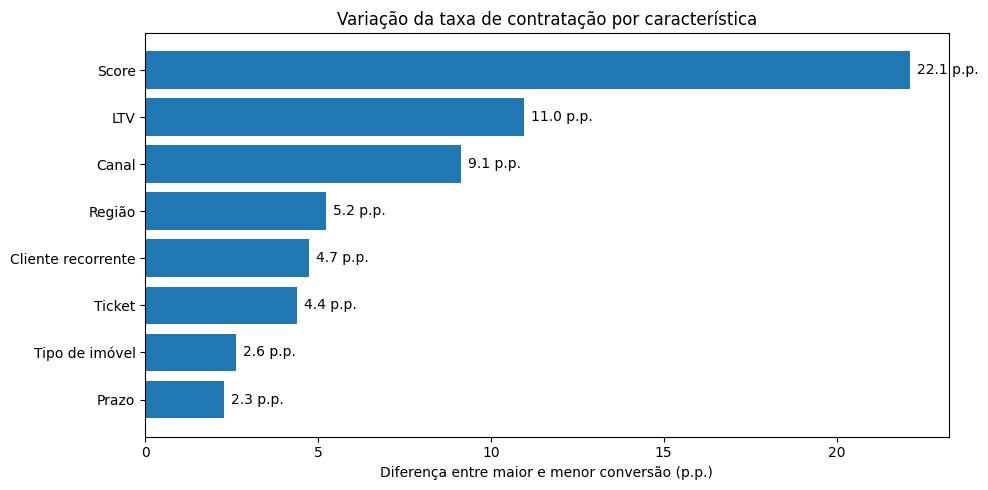

In [22]:
plt.figure(figsize=(10, 5))

plt.barh(
    resumo_associacoes["caracteristica"],
    resumo_associacoes["diferenca_pp"]
)

plt.title("Variação da taxa de contratação por característica")
plt.xlabel("Diferença entre maior e menor conversão (p.p.)")
plt.ylabel("")

plt.gca().invert_yaxis()

for i, valor in enumerate(resumo_associacoes["diferenca_pp"]):
    plt.text(
        valor + 0.2,
        i,
        f"{valor:.1f} p.p.",
        va="center"
    )

plt.tight_layout()
plt.show()

### Conclusão — características associadas à contratação

O **score de crédito** apresentou a associação descritiva mais forte com a contratação. Propostas com score abaixo de 600 tiveram conversão de aproximadamente **9,6%**, enquanto aquelas com score igual ou superior a 750 chegaram a **31,7%**.

O **LTV** também apresentou diferença relevante. Propostas acima do limite de 60% tiveram conversão de aproximadamente **12,1%**, enquanto a faixa entre 40% e 50% apresentou **23,0%**.

*Observação: o LTV foi calculado com base no valor solicitado. Como a base não informa o valor efetivamente contratado, propostas contratadas com LTV solicitado acima de 60% não necessariamente representam operações formalizadas acima da política.*

O **canal de origem** aparece como outro fator relevante. Correspondentes apresentaram conversão de **13,7%**, abaixo de todos os demais canais, enquanto Parcerias chegaram a aproximadamente **22,8%**.

Também foram observadas diferenças menores relacionadas à região, recorrência do cliente e ticket solicitado. Clientes recorrentes converteram aproximadamente **23,1%**, contra **18,3%** dos demais, enquanto propostas acima de R$ 600 mil apresentaram conversão inferior às propostas de menor ticket.

Tipo de imóvel e prazo apresentaram diferenças comparativamente menores nesta análise.

Os resultados representam associações descritivas e não devem ser interpretados como relações causais. As características das propostas podem estar relacionadas entre si. Por exemplo, o canal Correspondente apresenta também score médio inferior aos demais canais, o que pode explicar parte de sua menor conversão.

## 6. Recomendações acionáveis

As recomendações abaixo foram priorizadas considerando o tamanho da oportunidade, a proximidade da etapa com a contratação e a possibilidade de atuação operacional.

Os impactos apresentados são estimativas baseadas no comportamento histórico da própria base e em hipóteses explícitas. Não representam previsão garantida de resultado.

In [23]:
# ==========================================================
# RECOMENDAÇÃO 1
# Reduzir perdas na Formalização
# ==========================================================

perdas_formalizacao = df[
    df["etapa_funil_analise"] == 5
]

# Hipótese: recuperar 10% das propostas perdidas nesta etapa
taxa_recuperacao_formalizacao = 0.10

# Conversão histórica de quem chegou à etapa 5 ou além
chegaram_etapa5 = df[
    df["etapa_funil_analise"] >= 5
]

conversao_etapa5 = chegaram_etapa5["contratada"].mean()

conversao_valor_etapa5 = (
    df[df["contratada"]]["valor_solicitado"].sum()
    / chegaram_etapa5["valor_solicitado"].sum()
)

propostas_reativadas_1 = (
    len(perdas_formalizacao) * taxa_recuperacao_formalizacao
)

contratos_estimados_1 = (
    propostas_reativadas_1 * conversao_etapa5
)

valor_reativado_1 = (
    perdas_formalizacao["valor_solicitado"].sum()
    * taxa_recuperacao_formalizacao
)

volume_estimado_1 = (
    valor_reativado_1 * conversao_valor_etapa5
)


# ==========================================================
# RECOMENDAÇÃO 2
# Melhorar performance do canal Correspondente
# ==========================================================

correspondentes = df[
    df["canal_origem"] == "Correspondente"
]

demais_canais = df[
    df["canal_origem"] != "Correspondente"
]

conversao_correspondentes = correspondentes["contratada"].mean()
conversao_demais = demais_canais["contratada"].mean()

gap_conversao = (
    conversao_demais - conversao_correspondentes
)

# Hipótese conservadora:
# fechar apenas 50% da diferença para os demais canais
ganho_assumido = gap_conversao * 0.50

contratos_estimados_2 = (
    len(correspondentes) * ganho_assumido
)

ticket_medio_nao_contratado_corr = (
    correspondentes[
        ~correspondentes["contratada"]
    ]["valor_solicitado"].mean()
)

volume_estimado_2 = (
    contratos_estimados_2
    * ticket_medio_nao_contratado_corr
)


# ==========================================================
# RECOMENDAÇÃO 3
# Reduzir desistências e "sem retorno" na Análise de crédito
# ==========================================================

perdas_comerciais_etapa3 = df[
    (df["etapa_funil_analise"] == 3)
    & (df["status_final"].isin(["Sem retorno", "Desistiu"]))
]

# Hipótese: reativar 10% dessas propostas
taxa_recuperacao_etapa3 = 0.10

chegaram_etapa4 = df[
    df["etapa_funil_analise"] >= 4
]

conversao_etapa4 = chegaram_etapa4["contratada"].mean()

conversao_valor_etapa4 = (
    df[df["contratada"]]["valor_solicitado"].sum()
    / chegaram_etapa4["valor_solicitado"].sum()
)

propostas_reativadas_3 = (
    len(perdas_comerciais_etapa3)
    * taxa_recuperacao_etapa3
)

contratos_estimados_3 = (
    propostas_reativadas_3
    * conversao_etapa4
)

valor_reativado_3 = (
    perdas_comerciais_etapa3["valor_solicitado"].sum()
    * taxa_recuperacao_etapa3
)

volume_estimado_3 = (
    valor_reativado_3
    * conversao_valor_etapa4
)


# ==========================================================
# RESUMO
# ==========================================================

resultado_recomendacoes = pd.DataFrame({
    "Prioridade": [1, 2, 3],

    "Recomendação": [
        "Reduzir perdas na Formalização",
        "Melhorar performance de Correspondentes",
        "Reativar perdas comerciais na Análise de crédito"
    ],

    "Contratos adicionais estimados": [
        contratos_estimados_1,
        contratos_estimados_2,
        contratos_estimados_3
    ],

    "Volume potencial estimado": [
        volume_estimado_1,
        volume_estimado_2,
        volume_estimado_3
    ]
})

resultado_recomendacoes["Contratos adicionais estimados"] = (
    resultado_recomendacoes["Contratos adicionais estimados"]
    .round()
    .astype(int)
)

resultado_recomendacoes["Volume potencial estimado"] = (
    resultado_recomendacoes["Volume potencial estimado"]
    .apply(lambda x: f"R$ {x / 1_000_000:.1f} mi")
)

resultado_recomendacoes

,Prioridade,Recomendação,Contratos adicionais estimados,Volume potencial estimado
0,1,Reduzir perdas na Formalização,46,R$ 17.3 mi
1,2,Melhorar performance de Correspondentes,62,R$ 24.7 mi
2,3,Reativar perdas comerciais na Análise de crédito,41,R$ 15.6 mi


### Recomendações priorizadas

**1. Reduzir perdas na etapa de Formalização**

A Formalização apresenta a maior perda proporcional do funil: aproximadamente 41,5% do volume que chega à etapa não alcança a contratação.

Entre as 764 propostas que param nessa etapa, os desfechos são concentrados em **Documentação pendente** e **Desistência**.

A recomendação é implementar um processo mais ativo de acompanhamento da formalização, com checklist de documentos, lembretes automáticos, alertas para consultores e acompanhamento de propostas próximas ao abandono.

Como cenário conservador, assumi a recuperação de 10% das propostas atualmente perdidas nessa etapa. Aplicando a taxa histórica de conversão observada entre propostas que chegam à Formalização, o impacto estimado seria de aproximadamente **46 contratos adicionais**, representando cerca de **R$ 17,3 milhões em volume solicitado potencial**.

---

**2. Atuar especificamente sobre o canal de Correspondentes**

Correspondentes apresentaram conversão de aproximadamente **13,7%**, contra **21,4% nos demais canais**.

Além disso, o canal possui score médio inferior aos demais, indicando que parte da diferença pode estar relacionada ao perfil das propostas recebidas.

A recomendação é criar um processo de pré-qualificação e feedback para os Correspondentes, deixando mais claros critérios como score, LTV e perfil esperado da operação, além de acompanhar individualmente os parceiros com maior taxa de perda.

Para a estimativa de impacto, assumi que essas ações conseguiriam fechar apenas **50% da diferença de conversão** entre Correspondentes e os demais canais, elevando sua conversão de 13,7% para aproximadamente 17,5%.

Nesse cenário, seriam aproximadamente **62 contratos adicionais**, equivalentes a cerca de **R$ 24,7 milhões em volume solicitado potencial**.

---

**3. Reduzir desistências e falta de retorno durante a Análise de crédito**

A Análise de crédito concentra a maior perda absoluta do funil, com aproximadamente **R$ 649,8 milhões em volume solicitado**.

Dessas perdas, 1.101 propostas terminaram como **“Sem retorno” ou “Desistiu”**, somando aproximadamente **R$ 436,7 milhões**.

Como essas perdas não correspondem diretamente a reprovações de crédito, existe espaço para atuação comercial e operacional, por exemplo com cadências automáticas de contato, alertas de inatividade e registro estruturado do motivo de abandono.

Assumi a recuperação de 10% dessas propostas. Considerando que as propostas reativadas teriam a mesma taxa histórica de conversão das que chegaram à etapa seguinte, o impacto estimado seria de aproximadamente **41 contratos adicionais** e **R$ 15,6 milhões em volume solicitado potencial**.

> **Observação sobre os impactos:** as estimativas são cenários de referência, e não previsões causais. Os valores usam `valor_solicitado` como proxy de volume potencial, pois a base não contém o valor efetivamente contratado. Além disso, as três oportunidades podem se sobrepor, portanto seus impactos não devem ser simplesmente somados.